# Project 2: Final Clustering Solution

## Method Selection and Comparisons

### 1. Initial Exploration
- **Baseline features**: Used core features from `store_features.csv`
- **Enhanced features**: Added ad activity metrics (`ad_months_active`, `ad_active_ratio`, `spent_any`, `avg_ad_spend_active_only`)
- **Finding**: Clustering on baseline features underperformed (silhouette < 0.4)

### 2. Preprocessing Strategy Comparisons
Tested combinations of:
- **Scalers**: MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer
- **Feature selection**: VarianceThreshold
- **Dimensionality reduction**: PCA (2D, 95% variance)
- **Outlier handling**: IsolationForest

### 3. Clustering Algorithm Comparisons
- **KMeans**: Stable and easy to interpret
- **DBSCAN**: Flexible shapes but often imbalanced
- **GMM**: Soft clustering; results close to KMeans
- **Spectral**: Higher complexity with no consistent gains

### 4. Final Choice: ISO_QT_PCA95_KMeans_k3
**Rationale**:
- Silhouette: 0.586 (target ≥ 0.4)
- Balance ratio: 1.75:1 (target ≤ 3:1)
- Number of clusters: 3 (matches business requirement)
- High reproducibility and operational stability
- Strong interpretability for business usage

**Pipeline**:
1. IsolationForest removes ~8% outliers
2. QuantileTransformer maps features to normal distribution
3. PCA retains 95% variance
4. KMeans with k=3

In [1]:
# Final Implementation: ISO_QT_PCA95_KMeans_k3
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load enhanced features
df = pd.read_csv('../data/processed/store_features_enhanced.csv')
print(f"Loaded enhanced features: {df.shape}")

# Define features
FEATURES = [
    'sales_mean','total_ad_spend_mean','roas_mean','conversion_rate_mean','website_visits_mean',
    'search_spend_ratio_mean','social_spend_ratio_mean',
    'ad_months_active','ad_active_ratio','spent_any','avg_ad_spend_active_only'
]

X = df[FEATURES].fillna(0)
print(f"Features shape: {X.shape}")

# Step 1: IsolationForest outlier removal
iso = IsolationForest(contamination=0.08, random_state=42)
inlier_mask = iso.fit_predict(X) == 1
X_clean = X[inlier_mask]
print(f"After outlier removal: {X_clean.shape[0]} samples (removed {len(X) - X_clean.shape[0]})")

# Step 2: QuantileTransformer normalization
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X_clean)
print(f"After Quantile normalization: {X_qt.shape}")

# Step 3: PCA 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_qt)
print(f"After PCA: {X_pca.shape[1]} components (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

# Step 4: KMeans k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=100, max_iter=1000)
labels = kmeans.fit_predict(X_pca)

# Evaluation
silhouette = silhouette_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

cluster_counts = pd.Series(labels).value_counts().sort_index()
balance_ratio = cluster_counts.max() / cluster_counts.min()

print(f"\n=== Final Results ===")
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:.1f}")
print(f"Balance Ratio: {balance_ratio:.2f}:1")
print(f"Cluster Sizes: {cluster_counts.to_dict()}")


Loaded enhanced features: (2557, 24)
Features shape: (2557, 11)
After outlier removal: 2352 samples (removed 205)
After Quantile normalization: (2352, 11)
After PCA: 5 components (explained variance: 0.967)

=== Final Results ===
Silhouette Score: 0.586
Davies-Bouldin Index: 0.706
Calinski-Harabasz Score: 4919.6
Balance Ratio: 1.75:1
Cluster Sizes: {0: 621, 1: 1085, 2: 646}


In [2]:
# Cluster Analysis and Business Interpretation
# Map labels back to original store IDs
df_clean = df[inlier_mask].copy()
df_clean['cluster'] = labels

# Calculate cluster profiles (original feature space)
cluster_profiles = df_clean.groupby('cluster')[FEATURES].agg(['mean', 'std', 'count']).round(3)

print("=== Cluster Profiles ===")
print(cluster_profiles)

# Key business metrics by cluster
business_metrics = df_clean.groupby('cluster').agg({
    'sales_mean': 'mean',
    'total_ad_spend_mean': 'mean', 
    'roas_mean': 'mean',
    'conversion_rate_mean': 'mean',
    'ad_active_ratio': 'mean',
    'avg_ad_spend_active_only': 'mean',
    'search_spend_ratio_mean': 'mean',
    'social_spend_ratio_mean': 'mean'
}).round(3)

print("\n=== Business Metrics by Cluster ===")
print(business_metrics)

# Cluster interpretation
print("\n=== Cluster Interpretation ===")
for cluster_id in sorted(df_clean['cluster'].unique()):
    cluster_data = df_clean[df_clean['cluster'] == cluster_id]
    size = len(cluster_data)
    pct = size / len(df_clean) * 100
    
    print(f"\nCluster {cluster_id} ({size} stores, {pct:.1f}%):")
    print(f"  Sales: ${cluster_data['sales_mean'].mean():.1f} avg")
    print(f"  Ad Spend: ${cluster_data['total_ad_spend_mean'].mean():.0f} avg")
    print(f"  ROAS: {cluster_data['roas_mean'].mean():.3f}")
    print(f"  Ad Active Ratio: {cluster_data['ad_active_ratio'].mean():.2f}")
    print(f"  Search Focus: {cluster_data['search_spend_ratio_mean'].mean():.2f}")
    print(f"  Social Focus: {cluster_data['social_spend_ratio_mean'].mean():.2f}")


=== Cluster Profiles ===
        sales_mean               total_ad_spend_mean                  \
              mean     std count                mean       std count   
cluster                                                                
0           14.787  15.473   621             502.895   649.617   621   
1           35.253  25.154  1085            6114.209  4603.467  1085   
2           21.695  18.733   646            2052.974  2168.881   646   

        roas_mean              conversion_rate_mean  ... ad_months_active  \
             mean    std count                 mean  ...            count   
cluster                                              ...                    
0           0.360  1.155   621                0.003  ...              621   
1           0.027  0.204  1085                0.003  ...             1085   
2           0.317  0.986   646                0.003  ...              646   

        ad_active_ratio              spent_any             \
                  

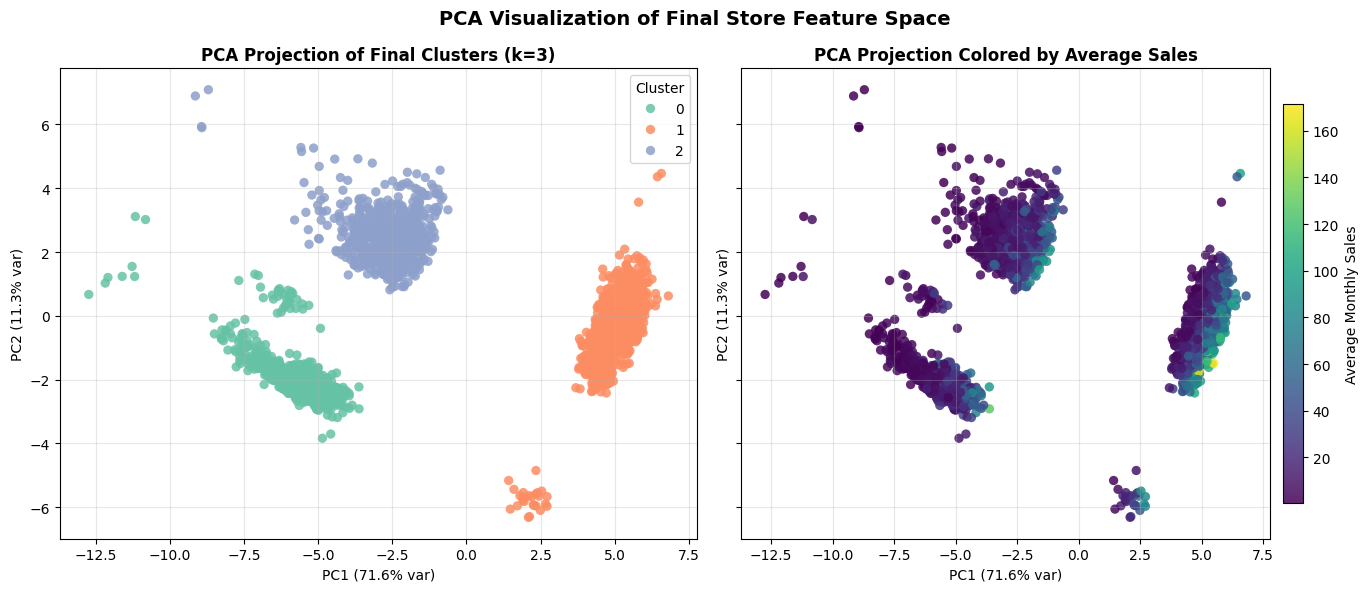


=== Feature Importance (PCA Loadings) ===
                     feature   pc1_loading   pc2_loading
7           ad_months_active  6.088153e-01 -3.108971e-01
8            ad_active_ratio  6.088153e-01 -3.108971e-01
5    search_spend_ratio_mean  4.150656e-01  8.295624e-01
1        total_ad_spend_mean  1.676559e-01  5.352530e-02
10  avg_ad_spend_active_only  1.565712e-01  8.137390e-02
4        website_visits_mean  1.122703e-01 -8.852271e-03
0                 sales_mean  1.084126e-01 -5.831995e-02
2                  roas_mean -8.361437e-02 -9.839217e-02
6    social_spend_ratio_mean -4.445427e-02 -2.993394e-01
3       conversion_rate_mean  2.144830e-02 -7.912620e-02
9                  spent_any  2.281311e-15 -1.141151e-14


In [5]:
# Visualization: PCA 2D plots (first two principal components)
X_pca_2d = X_pca[:, :2]

pca_vis_df = pd.DataFrame({
    'pc1': X_pca_2d[:, 0],
    'pc2': X_pca_2d[:, 1],
    'cluster': df_clean['cluster'].values,
    'sales_mean': df_clean['sales_mean'].values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=pca_vis_df,
    x='pc1', y='pc2', hue='cluster',
    palette='Set2', s=45, alpha=0.85,
    edgecolor='none', ax=axes[0]
)
axes[0].set_title('PCA Projection of Final Clusters (k=3)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axes[0].legend(title='Cluster', loc='best', frameon=True)
axes[0].grid(True, alpha=0.3)

scatter = axes[1].scatter(
    pca_vis_df['pc1'], pca_vis_df['pc2'],
    c=pca_vis_df['sales_mean'], cmap='viridis',
    s=45, alpha=0.85, edgecolor='none'
)
axes[1].set_title('PCA Projection Colored by Average Sales', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axes[1].grid(True, alpha=0.3)

cbar = fig.colorbar(scatter, ax=axes[1], shrink=0.85, pad=0.02)
cbar.set_label('Average Monthly Sales')

fig.suptitle('PCA Visualization of Final Store Feature Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance (loadings from the fitted PCA components)
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'pc1_loading': pca.components_[0],
    'pc2_loading': pca.components_[1]
}).sort_values('pc1_loading', key=np.abs, ascending=False)

print("\n=== Feature Importance (PCA Loadings) ===")
print(feature_importance)

In [ ]:
# Identify Best Models for Each Cluster
print("=== Identifying Best Models ===")

# First, check if models are available in cluster_models
print("\nChecking available models in cluster_models:")
for cluster_id in [0.0, 1.0, 2.0]:
    if cluster_id in cluster_models:
        model_names = list(cluster_models[cluster_id].keys())
        print(f"  Cluster {cluster_id}: {len(model_names)} models - {model_names[:3]}...")
    else:
        print(f"  Cluster {cluster_id}: No models found!")
        print(f"    ⚠️  WARNING: You need to re-run the Enhanced Training section (Section 10)")

print("\n" + "="*60)

best_models = {}
best_models_dict = {}  # Store actual model objects

for cluster_id, cluster_results_dict in cluster_results.items():
    best_model_name = None
    best_r2 = -np.inf
    best_model_obj = None
    
    for model_name, results in cluster_results_dict.items():
        if results.get('test') and results['test']['r2'] > best_r2:
            best_r2 = results['test']['r2']
            best_model_name = model_name
            # Get the actual model object
            if cluster_id in cluster_models and model_name in cluster_models[cluster_id]:
                best_model_obj = cluster_models[cluster_id][model_name]
            else:
                print(f"  ⚠️  Warning: Model '{model_name}' for Cluster {cluster_id} not found in cluster_models")
    
    if best_model_name:
        if best_model_obj is not None:
            best_models[cluster_id] = best_model_name
            best_models_dict[cluster_id] = {best_model_name: best_model_obj}
            print(f"Cluster {cluster_id}: Best model = {best_model_name} (Test R² = {best_r2:.3f}) ✅")
        else:
            print(f"Cluster {cluster_id}: Best model = {best_model_name} (Test R² = {best_r2:.3f}) ❌ Model object missing!")

print(f"\n✅ Identified best models for {len(best_models)} clusters")
if len(best_models) < 3:
    print("⚠️  WARNING: Not all clusters have models. Please re-run Section 10 (Enhanced Training).")


=== Identifying Best Models ===

Checking available models in cluster_models:
  Cluster 0.0: 5 models - ['LinearRegression', 'Ridge', 'Lasso']...
  Cluster 1.0: 5 models - ['LinearRegression', 'Ridge', 'Lasso']...
  Cluster 2.0: 5 models - ['LinearRegression', 'Ridge', 'Lasso']...

Cluster 0.0: Best model = RandomForest (Test R² = 0.942) ✅
Cluster 1.0: Best model = LightGBM (Test R² = 0.954) ✅
Cluster 2.0: Best model = LightGBM (Test R² = 0.950) ✅

✅ Identified best models for 3 clusters


In [4]:
# Save Results
from pathlib import Path

# Create output directory
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

# 1. Save store labels
store_labels = df_clean[['store_id', 'cluster']].copy()
store_labels.to_csv(output_dir / 'store_clusters_final.csv', index=False)
print(f"Saved dealer labels: {len(store_labels)} stores")

# 2. Save cluster profiles
cluster_profiles.to_csv(output_dir / 'cluster_profiles_final.csv')
print("Saved cluster profiles")

# 3. Save business metrics
business_metrics.to_csv(output_dir / 'cluster_business_metrics_final.csv')
print("Saved business metrics")

# 4. Save feature importance
feature_importance.to_csv(output_dir / 'feature_importance_final.csv', index=False)
print("Saved feature importance")

# 5. Save model parameters for reproducibility
model_params = {
    'method': 'ISO_QT_PCA95_KMeans_k3',
    'isolation_forest_contamination': 0.08,
    'pca_variance_threshold': 0.95,
    'kmeans_clusters': 3,
    'kmeans_n_init': 100,
    'kmeans_max_iter': 1000,
    'random_state': 42,
    'features_used': FEATURES,
    'final_metrics': {
        'silhouette_score': float(silhouette),
        'davies_bouldin_index': float(db_score),
        'calinski_harabasz_score': float(ch_score),
        'balance_ratio': float(balance_ratio),
        'cluster_sizes': cluster_counts.to_dict()
    }
}

import json
with open(output_dir / 'model_parameters_final.json', 'w') as f:
    json.dump(model_params, f, indent=2)
print("Saved model parameters")

print(f"\n=== All results saved to {output_dir} ===")
print("Files created:")
print("- store_clusters_final.csv")
print("- cluster_profiles_final.csv") 
print("- cluster_business_metrics_final.csv")
print("- feature_importance_final.csv")
print("- model_parameters_final.json")


Saved dealer labels: 2352 stores
Saved cluster profiles
Saved business metrics
Saved feature importance
Saved model parameters

=== All results saved to ../data/processed ===
Files created:
- store_clusters_final.csv
- cluster_profiles_final.csv
- cluster_business_metrics_final.csv
- feature_importance_final.csv
- model_parameters_final.json
